# Accuracy
Just like our ability to interpret experimental results relies on how well we understand the measurement uncertainties, our ability to solve problems numerically requires an understanding of the inherent uncertainties introduced by numerical computation.

## Representations of Numbers
As discussed [last week](./2b_computer.md):
The basic unit of information in a computer is a bit: 0 or 1
    + 8 bits = 1 byte

Different types of information require more bits/bytes to store.
+ Logical or boolean (True or False): can be stored in a single bit.
+ Integers (C/Fortran): standard in many languages is 4-bytes. This allows for $2^{32}-1$ distinct values.
     - This can store: -2,147,483,648 to 2,147,483,647 (signed)
     - Or it can store: 0 to 4,294,967,295 (unsigned)
+ Integers (Python): initialized as 64-bits, but can store arbitrary size as long as there is memory...
+ Floats: single precision (32-bit), double precision (64-bits)

:question:

```{embed} #ex_3-1
```

```{embed} #sol_3-1
```

In [1]:
def factorial(x):
    """ Makes a really big number"""
    if x == 0:
        return 1
    else:
        return x * factorial(x-1)

a = factorial(52)
print('a = ',a)
print('bit_length =', a.bit_length())

a =  80658175170943878571660636856403766975289505440883277824000000000000
bit_length = 226


## Floating Point Numbers
We can think of a floating point number as having the form:

$$
   \mathrm{significand} \times 10^\mathrm{exponent}
$$

Most computers follow the IEEE 754 standard for floating point, and we commonly work
with 32-bit and 64-bit floating point numbers (single and double precision).  These bits
are split between the signifcand and exponent as well as a single bit for the sign:



```{figure} https://upload.wikimedia.org/wikipedia/commons/d/d2/Float_example.svg
:align: center

Single-precision (32-bit)
```

```{figure} https://upload.wikimedia.org/wikipedia/commons/thumb/a/a9/IEEE_754_Double_Floating_Point_Format.svg/3840px-IEEE_754_Double_Floating_Point_Format.svg.png
:align: center

Double-precision (64-bit)
```

Since the number is stored in binary, we can think about expanding a floating point number in powers of 2 in order to represent it:

$$
   0.1 \sim (1 +
             1 \cdot 2^{-1} +
             0 \cdot 2^{-2} +
             0 \cdot 2^{-3} +
             1 \cdot 2^{-4} +
             1 \cdot 2^{-5} + \ldots) \times 2^{-4}
$$







We can even query python to see what the allowable range of values is that can be stored in a float.
Outside of those ranges, our number can trigger either an:
+ **Underflow Error**: below the minimum range
+ **Overflow Error**: above the maximum range

In [2]:
import sys
b = 0.1
print(type(b))
print("{:30.20}".format(b))
print(sys.float_info)

<class 'float'>
        0.10000000000000000555
sys.float_info(max=1.7976931348623157e+308, max_exp=1024, max_10_exp=308, min=2.2250738585072014e-308, min_exp=-1021, min_10_exp=-307, dig=15, mant_dig=53, epsilon=2.220446049250313e-16, radix=2, rounds=1)


Special numbers:
+ `nan`: not a number, for `0/0` or `sqrt(-1)`
+ `inf`: infinity, for overflow such as:`1/0`

These will replace underflowed or overflowed errors, but can not be used for computation. 
```{warning}
If you have a `nan` in a data structure, the computation will continue, but any operations with `nan` always yield more `nan`!
```

### Machine Precision
You may sometimes hear that numerical calculations are accurate to *at best* machine precision, $\epsilon$. 
This refers to the relative error introduced by having a finite smallest possible number that we can represent. 

For double precision, we have 52 bits for the significand. Thus, the smallest number compared to ``1`` we can represent is given by:

$$
   2^{-52} \approx 2.22\times 10^{-16}
$$

but the IEEE 754 format always expresses the significand such that the first bit is ``1`` (by adjusting the exponent) so that it doesn't need
to store that ``1``, giving us an extra bit of precision, so the machine epsilon is:

$$
  \epsilon =  2^{-53} \approx 1.11\times 10^{-16}
$$


```{note}
Machine error refers to a *relative* error, so for a number like $1000$ we could only add
$1000 \times \epsilon = 1.1\times 10^{-13}$ to it before it became indistinguishable from $1000$.

$$
   \mathrm{relative roundoff error} = \frac{|\mathrm{true number} - \mathrm{computer representation} |}
      {|\mathrm{true number}|} \le \epsilon
$$
```

There are [varying definitions of machine epsilon](https://en.wikipedia.org/wiki/Machine_epsilon#Alternative_definitions_for_epsilon) which differ by a factor of 2.


In [3]:
# Example code to find epsilon
x = 1.0
eps = 1.0
while x + eps != x:
    eps = eps/2.0
print(2*eps)

2.220446049250313e-16


:question:
```{embed} #ex_3-2
```

```{embed} #sol_3-2
```

```{note}
Math is not associative in floating point. Consider:
        $$(a + b) + c$$
        vs.
        $$a + (b + c)$$
with `a = 1.0` `b = -1.0`, and `c = 2.e-15`

```

In [4]:
a = 1.0
b = -1.0
c = 2.e-15

print((a+b) + c)
print(a + (b+c))

2e-15
1.9984014443252818e-15


## Numerical Error
This limited precision plays into two main types of numerical errors:
+ Roundoff error
+ Truncation error

### Roundoff Error
For many successive computations, the relative roundoff accumulates. When the accumulated error is no longer small compared to the values of interest, this becomes a major problem in a calculation.

```{note}
:class: dropdown
For this reason, direct numerical integration of few-body systems can not be solved accurately for an arbitrarily long time period as errors accumulate over successive iterations. This is particularly salient for computing orbital dynamics over billions of years. Specific algorithms have been developed to reduce the growth of numerical errors in these schemes.
```




<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} #icc_3-1
```

In [12]:
from math import exp

def factorial(x):
    """ Makes a really big number"""
    if x == 0:
        return 1
    else:
        return x * factorial(x-1)



def S(x,n_iter=100):
    """Compute a Taylor series expansion of e^x truncated at n_iter"""
    ### your code here
    return 

print(exp(5))
print(S(5))

print(exp(-24))
print(S(-24))

148.4131591025766
148.41315910257657
3.775134544279098e-11
-2.364182205523906e-07


What's going on here? By definition, this [Taylor series expansion converges](https://en.wikipedia.org/wiki/Taylor_series#Calculation_of_Taylor_series) for all $x$!   
Mathematically speaking, we should converge to the correct solution as we increase $n$. 

You can see here, that we do converge, but to an entirely incorrect value.

This is a numerical problem:
The Taylor Series is a sum of "large" floating point numbers whose value depends on resolving their relative difference. As we are limited by machine precision, this successive calculation means the round-off error dominates the calculation. 

In [15]:
for n in [10,100,500,1000]:
    print('n = {}: S(x)={}'.format(n,S(-24,n_iter=n)))

n = 10: S(x)=12223037.662857141
n = 100: S(x)=-2.364182205523906e-07
n = 500: S(x)=-2.3641822055239277e-07
n = 1000: S(x)=-2.3641822055239277e-07


:question:

```{embed} #ex_3-3
```

```{embed} #sol_3-3
```


#### Reducing Roundoff Error
As we just saw, often we can reduce roundoff error by changing the order of operations or using algebraically equivalent expressions that have better roundoff properties. 

We know that when we're subtracting two very large, nearly identical numbers, this can result in a loss of precision.

Let's consider:
$$f = a^2 - b^2$$
and the equivalent:
$$g = (a - b)(a + b)$$

We want to avoid situations that depend on the cancelation of two large and nearly identical numbers! 


```{embed} #ex_3-4
```


In [45]:
a = 1.e18
b = a + 1.e9

f = a**2 - b**2
g = (a-b)*(a+b)

print("f={}, g={}, error = {}".format(f,g,(f-g)/g))

f=-1.9999999769683095e+27, g=-2.000000001e+27, error = -1.201584528005781e-08


<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} #icc_3-2
```

Alternative expression:
$$V = ...$$

Test your expression against the value of the original below.

In [56]:
from math import pi
r_l= 1e10
delta_r = 1e-5
r_r = r_l + delta_r

V_0 = 4. * pi * (r_r**3 - r_l**3) / 3.
V_1 = 0.0 # replace here

print(V_0, V_1)

1.1790396253380734e+16 1.2566370614359184e+16 1.2566370614359184e+16


```{note}
:class: dropdown
Calculus enjoyers may recall that the differential volume element for a spherically symmetric coordinate is defined as:
$$dV = 4 \pi r^2 dr $$
which is valid for infinitesimally small $dr$. 

You can check for yourself that if you take $r$ to be the midpoint of $r_r$ and $r_l$, for small values of $\Delta r$, our factored expression converges to the same value as:

$$dV = 4\pi \Delta r \left ( \frac{r_r + r_l}{2} \right)^2$$
```

### Truncation Error

Consider Taylor expanding a function $f(x)$:

$$f(x + h) = f(x) + h f^\prime(x) + \frac{h^2}{2} f^{\prime\prime}(x) + \ldots$$

Rearranging this, we can solve for the derivative $f^\prime(x)$:

$$f^\prime(x) = \frac{f(x+h) - f(x)}{h} - \frac{h}{2} f^{\prime\prime}(x) + \ldots$$


If you recall, the definition of a derivative from calculus is given by the limit of a similar expression as $h$ goes to 0. 
$$ f^\prime(x) = \lim_{h \to 0} \frac{ f(x+h) - f(h)}{h} $$

But numerically, we can't take $h$ to $0$, as we don't have continous variables or functions: we are **discretized** in $x$. 
So we use the Taylor series expansion as an alternative definition. 

However, we can't write sum to infinity on a computer either, so have to decide which terms to keep.

We can write a definition of a numerical derivative to first-order accuracy:

$$f^\prime(x) \approx \frac{f(x+h) - f(x)}{h} + \mathcal{O}(h)$$

where $\mathcal{O}(h)$ here means that the error in this approximation for the derivative is proportion to $h$. 

**This is an example of truncation error -- the terms we are ignoring are an error in our approximation of our expression.**

<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} #icc_3-3
```

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


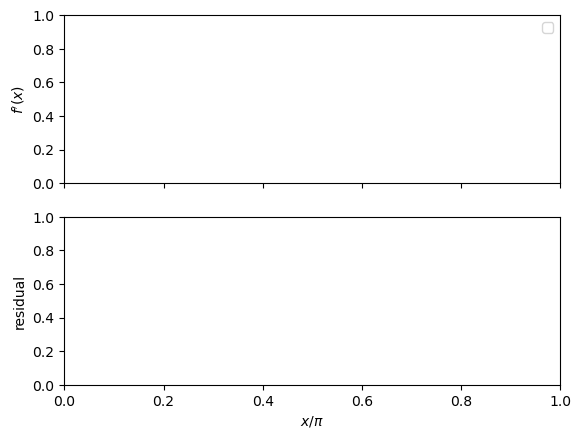

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from math import pi

def f(x):
    """our function to numerically differentiate"""
    return np.sin(x)

def fprime(x):
    """the analytic derivative of f"""
    return np.cos(x)

def Dh(x, h):
    """a discrete approximation to the derivative at x"""
    return # your code here

h = 0.5
x = np.arange(0,2*pi,h)

fig,ax = plt.subplots(2,sharex=True)

##

ax[0].set_ylabel(r'$f^\prime(x)$')

##

ax[1].set_ylabel('residual')
ax[1].set_xlabel(r'$x/\pi$')
ax[0].legend()

As you make these plots, play around with varying $h$ and ask yourself:
+ What trends can you spot with $h$?
+ What is the typical range of the residual values with respect to $h$?
+ How does the residual behave across the curve?
+ Which regions are more or less accurate? Why? 

<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} #icc_3-4
```

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'error')

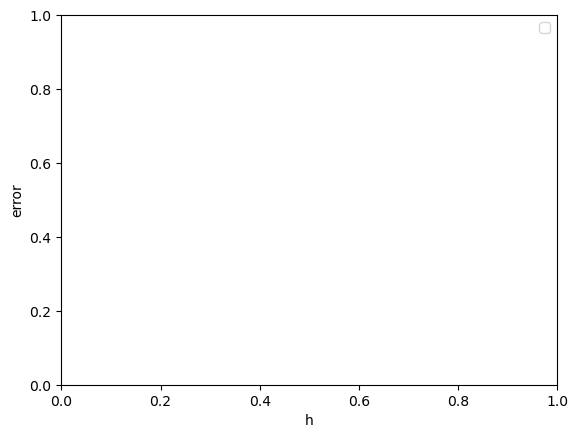

In [2]:
# generate a set of h's from 1.e-18 to 1
hs = np.logspace(-18, 0, 1000)
eps = 1.11e-16

# we'll look at the error at pi/3
x = np.pi/3

# compute the relative error
# err = ...

# plot the error vs h
fig, ax = plt.subplots()
#ax.loglog(hs, err)
#ax.loglog(hs,hs,color='gray',ls='dashed')


#ax.axvline(eps,color='gray',ls='dotted',label=r'$\epsilon$')

ax.legend()
ax.set_xlabel("h")
ax.set_ylabel("error")

Once you have your plot working, evaluate the trends:
+ for $h > k$, we see the (expected) behavior in which the error is of order $h$. (This is the truncation error).
+ for $h< k$, as we approach some value $m$ from the right, the error fluctuates somewhat, but generally grows towards lower values!
+ for $h \leq m$, the error is on the order of the answer. (We can probably guess that the behavior of the left hand side might be telling us something about the roundoff error)

If roundoff error is kicking in, we have some clue of what a reasonable number to compare to might be: $\epsilon$.

+ What are $k$ and $m$ in terms of epsilon? (You can take a guess by placing some vertical lines on the plot)

## Speed
Besides not having infinite memory, computers also don’t have infinite speed. [Last week](./2b_computer.md) we talked about how processing power is often measured in FLOPS: floating point operations per second. 

More accurate calculations typically require computing more terms (which means more operations!), so it is often the case that we compromise between accuracy and speed. 

We can generally estimate how long a piece of code will take to run -- i.e. how it **scales** by comparing it to the same one on fewer operations.

```{tip}
Timing can be down with the `time` module (see also: [PS1](../psets/ps1.md) for an example)
````{code-block} python
import time
start_time = time.time()
### your code
print(time.time()-start_time)
````
```

<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} #icc_3-5
```

In [94]:
import time

###

times = []
#for ...



0.00043487548828125
0.2660517692565918
281.7081661224365


Making a prediction based on runs of a code with increased number of operations is part of **benchmarking** a code. 

It is often a requirement for applying for computing time. 

If your calculation for $N=100$ took around $281$ seconds, you should have estimated something on the order of $\sim 2 \times 10^{5}$ seconds (several days!) for $N=10^4$. 

But, we don't have to be dejected yet! 
The `numpy` library offers us a handy way out. If you have an array, `numpy` *vectorizes* operations along dimensions, which saves a lot of time!

```{tip}
In practice, if you are performing operations within an array, you should never use a loop when there is a `numpy` function that can do it instead!
```


<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} #icc_3-6
```

You should see that the scaling is much much shallower for `numpy`, it should be conceivable to do $N=10^4$ within a reasonable timescale!